---
authors: Freek Pols
---
# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [4]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
In de laatste regel wordt één extra deeltje toegevoegd aan de lijst `particles`.  
Dit deeltje is rood, staat in het midden van de box, heeft een grote massa (20.0) en begint zonder snelheid. Het representeert dus het Browniaanse deeltje: een rood deeltje dat zwaardere is dan de andere 39 blauwe deeltjes en dat door botsingen met de lichte blauwe deeltjes in beweging komt. 
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



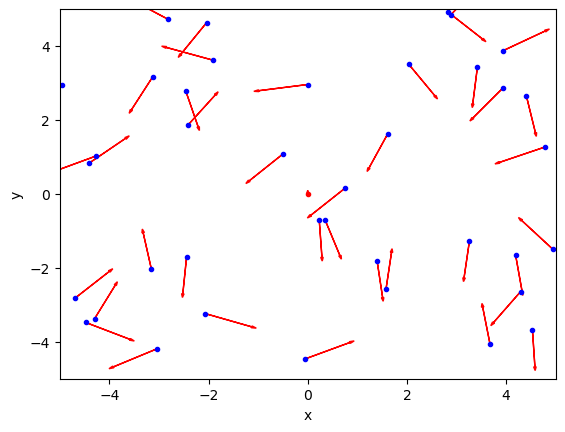

In [6]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
               particle_object.v[0],particle_object.v[1], 
               head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
De code die met comments ervoor staat tekent pijltjes bij elk deeltje. 
Die pijltjes laten de richting en grootte van de snelheid zien. 
Als je de comments weghaalt, zie je dus niet alleen de posities van de deeltjes, maar ook bijbehorende snelheidsvector. Die voor iedere deeltje hetzelfde is, omdat bij het aanmaken van de deeltjes eerst een x‑snelheid gekozen wordt, maar y-snelheid is afhankelijk van de x-snelheid door de volgende formule: vx² + vy² = v₀², waarbij v_0 waarde 0 werd gegeven, dus hierdoor hebben alle deeltjes dezelfde snelheidsgrootte (namelijk v-0), alleen de richting verschilt.
```

We gaan nu de functies van de simulatie weer aanroepen:

In [13]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0] # x-afstand tussen 2 deeltjes
    dy = self.r[1] - other.r[1] # y-afstand tussen 2 deeltjes
    rr = self.R + other.R # Afstand tussen de middelpunten van de 2 deeltjes
    return  dx**2+dy**2 < rr**2 # Als de afstand kleiner is dan de som van de stralen dan is er sprake van botsing.
        
def particle_collision(p1: ParticleClass, p2: ParticleClass): # Zo ja: bewegen ze naar elkaar toe of van elkaar af?
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r # Verschil in positie (array)
    delta_v = p1.v - p2.v # Verschil in snelheid (array)
    dot_product = np.dot(delta_r, delta_v) # Projectie van snelheidsvector op richtingsvector:
    # Dit bepaalt dus in hoeverre snelheid op positie vector ligt en of de deeltjes dan naar elkaar toe of van elkaar af bewegen.
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing, dus 'return' command!
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return

    # Als dot_product >=! 0, dan dot_product negatief, dus botsing!
    # # Daarom elastische botsing in 2D gebruiken, dus impuls- en energiebehoud geldt:
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    collisions = 0
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                collisions += 1

In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

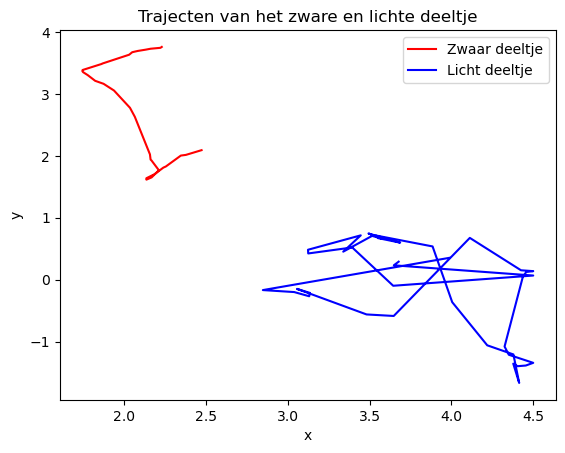

In [26]:
# Tracken van het zware deeltje
track_x = []
track_y = []

# Tracken van een licht deeltje
track_x_light = []
track_y_light = []

# Beginpositie opslaan van het lichte deeltje
track_x_light.append(particles[0].r[0])
track_y_light.append(particles[0].r[1])

# Trackinglijst voor aantal botsingen per tijdstap
collision_counts = []

# Simulatieloop
for i in range(400):
    # Update alle deeltjes
    for p in particles:
        p.update_position()
        p.boxcollision()

    # Tel botsingen
    collisions_this_step = 0
    num_particles = len(particles)
    for a in range(num_particles):
        for b in range(a+1, num_particles):
            if collide_detection(particles[a], particles[b]):
                particle_collision(particles[a], particles[b])
                collisions_this_step += 1

    # Sla aantal botsingen van deze tijdstap op
    collision_counts.append(collisions_this_step)

    # Posities bijhouden
    track_x.append(particles[N-1].r[0])      # Zwaar deeltje
    track_y.append(particles[N-1].r[1])
    track_x_light.append(particles[0].r[0])  # Licht deeltje
    track_y_light.append(particles[0].r[1])

plt.figure()
plt.plot(track_x,track_y,'r', label='Zwaar deeltje')
plt.plot(track_x_light, track_y_light, 'b', label='Licht deeltje')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajecten van het zware en lichte deeltje')
plt.legend()
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
Overeenkomsten:
- Hun trajecten zijn beide onvoorspelbaar en chaotisch.

Verschillen:
- Het lichte deeltje verandert sneller van richting en beweegt veel meer door de figuur dan het zware deeltje.
- Het zware deeltje beweegt trager en minder ver. Dit komt omdat het zware deeltje meer massa heeft en dus minder sterk reageert op botsingen (kijkend naar richtingverandering).

Na het meermaals runnen van de simulatie: 
- Het patroon van beweging is steeds anders, omdat de startcondities en botsingen willekeurig zijn.
- Toch zie je steeds hetzelfde algemene gedrag: het lichte deeltje is heel beweeglijk, 
het zware deeltje gaat uiteindelijk toch bewegen door de botsingen met zoveel andere deeltjes. 
```

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

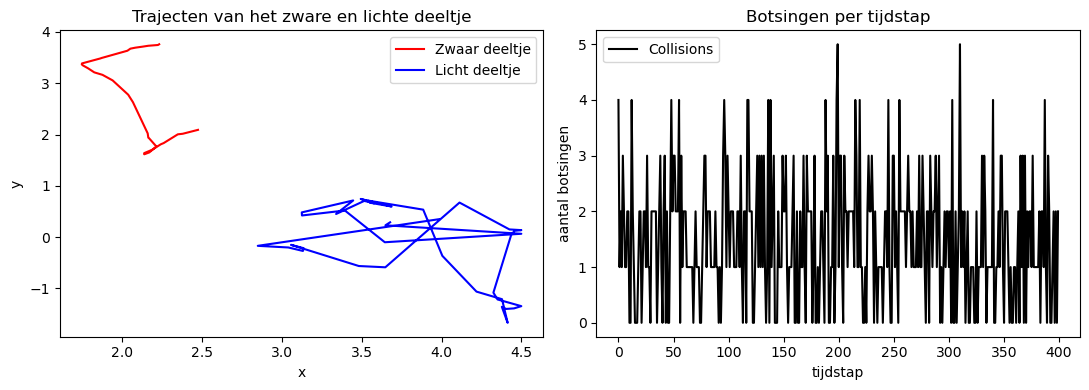

In [28]:
# Het nogmaals plotten van de trajecten van beide deeltjes:
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(track_x,track_y,'r', label='Zwaar deeltje')
plt.plot(track_x_light, track_y_light, 'b', label='Licht deeltje')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajecten van het zware en lichte deeltje')
plt.legend()

plt.subplot(1,2,2)
plt.plot(collision_counts, 'k', label='Collisions')
plt.xlabel("tijdstap")
plt.ylabel("aantal botsingen")
plt.title("Botsingen per tijdstap")
plt.legend()
plt.tight_layout()
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


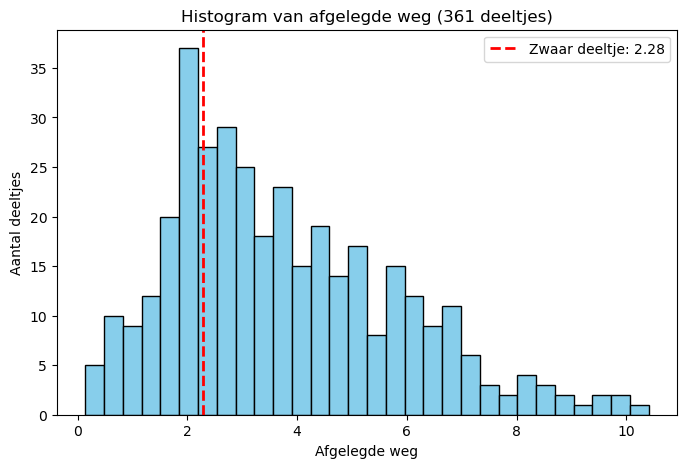

In [29]:
# Randvoorwaarden
N = 361
Box_size_0 = 30              # grotere box voor meer deeltjes
Box_length_0 = Box_size_0/2
Box_length = Box_length_0
dt = 0.04
v_0 = 1

# Aanmaken van deeltjes
particles = []
for i in range(N-1):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = Box_length_0 * np.random.uniform(-1, 1, 2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=0.5, c='blue'))

# Zwaar deeltje in het midden
particles.append(ParticleClass(m=20.0, v=[0, 0], r=[0, 0], R=0.5, c='red'))

# Beginposities opslaan
start_positions = np.array([p.r.copy() for p in particles])

# Simulatieloop
for i in range(400):
    for p in particles:
        p.update_position()
        p.boxcollision()
    handle_collisions(particles)

# Eindposities opslaan
end_positions = np.array([p.r.copy() for p in particles])

# Afgelegde weg berekenen
distances = np.linalg.norm(end_positions - start_positions, axis=1)

# Afstand zwaar deeltje
heavy_distance = distances[N-1]

# Histogram plotten
plt.figure(figsize=(8,5))
plt.hist(distances, bins=30, color='skyblue', edgecolor='black')
plt.axvline(heavy_distance, color='red', linestyle='--', linewidth=2,
            label=f"Zwaar deeltje: {heavy_distance:.2f}")
plt.xlabel("Afgelegde weg")
plt.ylabel("Aantal deeltjes")
plt.title("Histogram van afgelegde weg (361 deeltjes)")
plt.legend()
plt.show()


En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

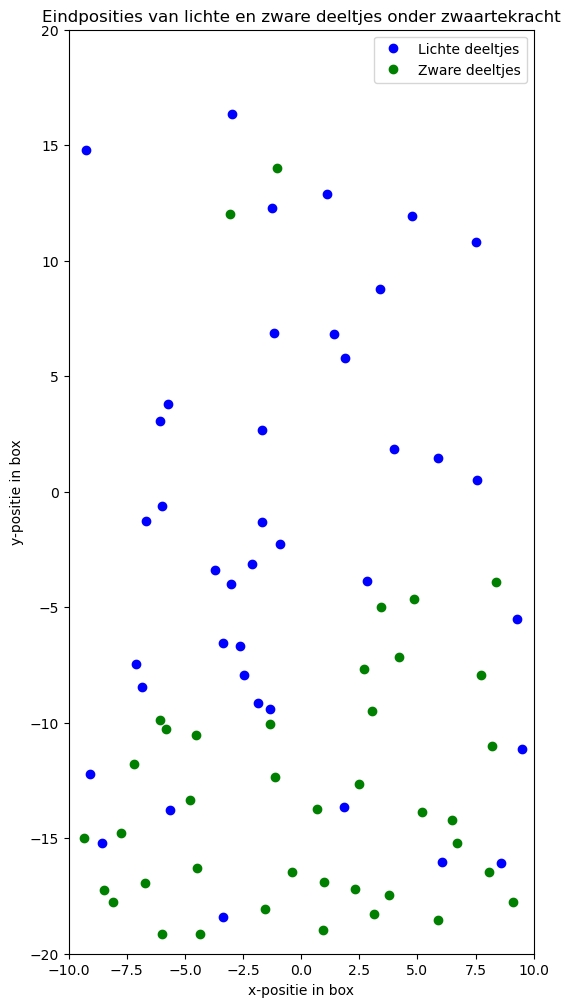

In [34]:
# Box 2x zo hoog als breed
Box_size_x = 20
Box_size_y = 40
Box_length_x = Box_size_x / 2
Box_length_y = Box_size_y / 2
dt = 0.04
g = 5.0   # artificieel grote zwaartekracht

class ParticleClass:
    def __init__(self, m, v, r, R, c):
        self.m = m
        self.v = np.array(v, dtype=float)
        self.r = np.array(r, dtype=float)
        self.R = R
        self.c = c

    def update_position(self):
        # zwaartekracht in y-richting
        self.v[1] += -g * dt
        self.r += self.v * dt

    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length_x:
            self.v[0] = -self.v[0]
            self.r[0] = np.sign(self.r[0]) * (Box_length_x - self.R)
        if abs(self.r[1]) + self.R > Box_length_y:
            self.v[1] = -self.v[1]
            self.r[1] = np.sign(self.r[1]) * (Box_length_y - self.R)

# Aanmaken van 2 groepen
particles = []
N = 80
v_0 = 1

# Lichte deeltjes
for i in range(N//2):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.uniform(-v_0, v_0)
    pos = [np.random.uniform(-Box_length_x, Box_length_x),
           np.random.uniform(-Box_length_y, Box_length_y)]
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=0.5, c='blue'))

# Zware deeltjes
for i in range(N//2):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.uniform(-v_0, v_0)
    pos = [np.random.uniform(-Box_length_x, Box_length_x),
           np.random.uniform(-Box_length_y, Box_length_y)]
    particles.append(ParticleClass(m=10.0, v=[vx, vy], r=pos, R=0.5, c='green'))

# Simulatieloop
for step in range(400):
    for p in particles:
        p.update_position()
        p.boxcollision()
    handle_collisions(particles)

# Plot eindposities
plt.figure(figsize=(6,12))

# Plot lichte deeltjes
label_l = False
label_z = False

for p in particles:
    if p.m == 1.0:   # massa 1 = licht
        if not label_l:
            plt.plot(p.r[0], p.r[1], 'o', color='blue', label='Lichte deeltjes') # Maar één label!
            label_l = True
        else:
            plt.plot(p.r[0], p.r[1], 'o', color='blue')
    elif p.m == 10.0: # massa 
        if not label_z:
            plt.plot(p.r[0], p.r[1], 'o', color='green', label='Zware deeltjes') # Maar één label!
            label_z = True
        else:
            plt.plot(p.r[0], p.r[1], 'o', color='green')

# Aslimieten en labels
plt.xlim(-Box_length_x, Box_length_x)
plt.ylim(-Box_length_y, Box_length_y)
plt.xlabel("x-positie in box")
plt.ylabel("y-positie in box")
plt.title("Eindposities van lichte en zware deeltjes onder zwaartekracht")
plt.legend()
plt.show()